In [1]:
from pathlib import Path
import pickle

try:
    START_DIR = Path(__file__).resolve().parent
except NameError:
    START_DIR = Path.cwd().resolve()

DATA_FILE = Path("data") / "RML2016.10a_dict.pkl"
for candidate in (START_DIR, *START_DIR.parents):
    if (candidate / DATA_FILE).exists():
        BASE_DIR = candidate
        break
else:
    raise FileNotFoundError(f"Dataset not found under {START_DIR} or its parents")

DATA_PATH = BASE_DIR / DATA_FILE

print("Base dir:", BASE_DIR)
print("Data path:", DATA_PATH)

with open(DATA_PATH, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print("✅ Loaded successfully")
print("Total keys:", len(data))

Base dir: D:\amr-explainable
Data path: D:\amr-explainable\data\RML2016.10a_dict.pkl
✅ Loaded successfully
Total keys: 220


In [7]:
import numpy as np 
X = []
y = []
snr = []

for (mod, snr_val), signals in data.items():
    X.append(signals)  # append full batch (1000 samples)
    
    # create labels for this batch
    y.extend([mod] * signals.shape[0])
    snr.extend([snr_val] * signals.shape[0])

# Convert efficiently
X = np.vstack(X)   # fast stacking
y = np.array(y)
snr = np.array(snr)

print("✅ Conversion done")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("snr shape:", snr.shape)

print("Modulations:", sorted(set(y)))

print("SNR range:", sorted(set(snr)))

print("One sample shape:", X[0].shape)
print("One label:", y[0])
print("One SNR:", snr[0])

✅ Conversion done
X shape: (220000, 2, 128)
y shape: (220000,)
snr shape: (220000,)
Modulations: [np.str_('8PSK'), np.str_('AM-DSB'), np.str_('AM-SSB'), np.str_('BPSK'), np.str_('CPFSK'), np.str_('GFSK'), np.str_('PAM4'), np.str_('QAM16'), np.str_('QAM64'), np.str_('QPSK'), np.str_('WBFM')]
SNR range: [np.int64(-20), np.int64(-18), np.int64(-16), np.int64(-14), np.int64(-12), np.int64(-10), np.int64(-8), np.int64(-6), np.int64(-4), np.int64(-2), np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18)]
One sample shape: (2, 128)
One label: QPSK
One SNR: 2


In [3]:
import numpy as np

# Avoid division by zero
max_vals = np.max(np.abs(X), axis=(1,2), keepdims=True)
max_vals[max_vals == 0] = 1

X_norm = X / max_vals

print("✅ Normalization done")
print("Range:", X_norm.min(), "to", X_norm.max())

✅ Normalization done
Range: -1.0 to 1.0


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("✅ Encoding done")
print("Classes:", le.classes_)
print("Total classes:", len(le.classes_))

✅ Encoding done
Classes: ['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']
Total classes: 11


In [5]:
from sklearn.model_selection import train_test_split

# Stratify by both modulation and SNR. This keeps every class/SNR bucket balanced
# across splits, which matters a lot for RadioML accuracy reporting.
strata = np.array([f"{label}_{snr_value}" for label, snr_value in zip(y_encoded, snr)])

# Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp, snr_train, snr_temp, strata_train, strata_temp = train_test_split(
    X_norm, y_encoded, snr, strata,
    test_size=0.3,
    random_state=42,
    stratify=strata,
)

# Val (15%) + Test (15%)
X_val, X_test, y_val, y_test, snr_val, snr_test, strata_val, strata_test = train_test_split(
    X_temp, y_temp, snr_temp, strata_temp,
    test_size=0.5,
    random_state=42,
    stratify=strata_temp,
)

print("Split done")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Split done
Train: (154000, 2, 128)
Val: (33000, 2, 128)
Test: (33000, 2, 128)


In [8]:
train_mask = snr_train >= 0

X_train = X_train[train_mask]
y_train = y_train[train_mask]
snr_train = snr_train[train_mask]

val_mask = snr_val >= 0

X_val = X_val[val_mask]
y_val = y_val[val_mask]
snr_val = snr_val[val_mask]

test_mask = snr_test >= 0

X_test = X_test[test_mask]
y_test = y_test[test_mask]
snr_test = snr_test[test_mask]

In [6]:
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (154000, 2, 128)
Val: (33000, 2, 128)
Test: (33000, 2, 128)


In [8]:
print(X_train.shape, y_train.shape)

(77000, 2, 128) (77000,)


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool

import numpy as np



In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [8]:
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).long()

X_val = torch.from_numpy(X_val).float()
y_val = torch.from_numpy(y_val).long()

In [9]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=128,
    shuffle=True,
    pin_memory=True,
    num_workers=2
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=128,
    pin_memory=True
)

In [10]:
def build_edge_index(n):
    edges = []
    for i in range(n-1):
        edges.append([i, i+1])
        edges.append([i+1, i])
    return torch.tensor(edges).t().contiguous()

def batch_edge_index(edge_index, B, N):
    return torch.cat([edge_index + i*N for i in range(B)], dim=1)

edge_index = build_edge_index(128).to(device)

In [11]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data

# ---------------- CNN ----------------
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(2, 64, 3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 128, 3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Conv1d(128, 128, 5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Conv1d(128, 128, 7, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Dropout(0.4)
        )

    def forward(self, x):
        return self.net(x)


# ---------------- GNN ----------------
class GNNModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = GCNConv(385, 128) 
        self.conv2 = GCNConv(128, 64)
        self.conv3 = GCNConv(64, 64)

        self.fc = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, data, batch):
        x, edge_index = data.x, data.edge_index

        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))

        x = global_mean_pool(x, batch)

        return self.fc(x)


# ---------------- FULL MODEL ----------------
class CNN_GRU_GNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = CNNFeatureExtractor()

        # 🔥 NEW: GRU (temporal modeling)
        self.gru = nn.GRU(
            input_size=128,
            hidden_size=192,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.gnn = GNNModel(num_classes)

    def forward(self, x, edge_index):

        # CNN
        features = self.cnn(x)  # (B, 128, 128)

        # 🔥 GRU expects (B, N, C)
        x = features.permute(0, 2, 1)

        x, _ = self.gru(x)  

        B, N, C = x.shape

        # reshape for GNN
        x = x.reshape(B * N, C)

        # positional encoding
        pos = torch.arange(N).float().to(x.device) / N
        pos = pos.unsqueeze(0).repeat(B, 1).reshape(-1, 1)

        x = torch.cat([x, pos], dim=1)

        # batch graph
        edge = batch_edge_index(edge_index, B, N)

        data = Data(x=x, edge_index=edge)

        batch = torch.arange(B).repeat_interleave(N).to(x.device)

        return self.gnn(data, batch)

In [12]:
model = CNN_GRU_GNN(num_classes=len(le.classes_)).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

scaler = torch.amp.GradScaler("cuda")

In [16]:
epochs = 25
best_val_acc = 0
patience = 8
no_improve = 0

use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda") if use_amp else None

for epoch in range(epochs):

    # ================= TRAIN =================
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for Xb, yb in train_loader:

        Xb = Xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()

        if use_amp:
            with torch.amp.autocast("cuda"):
                out = model(Xb, edge_index)
                loss = criterion(out, yb)
        else:
            out = model(Xb, edge_index)
            loss = criterion(out, yb)

        # backward
        if use_amp:
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # ✅ FIX: correct loss accumulation
        train_loss += loss.item() * Xb.size(0)

        preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    # ✅ FIX: average loss
    train_loss /= total
    train_acc = correct / total

    scheduler.step()

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for Xb, yb in val_loader:

            Xb = Xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            if use_amp:
                with torch.amp.autocast("cuda"):
                    out = model(Xb, edge_index)
                    loss = criterion(out, yb)
            else:
                out = model(Xb, edge_index)
                loss = criterion(out, yb)

            # ✅ FIX: correct loss accumulation
            val_loss += loss.item() * Xb.size(0)

            preds = out.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    # ✅ FIX: average loss
    val_loss /= total
    val_acc = correct / total

    # ================= PRINT =================
    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} | "
        f"LR {scheduler.get_last_lr()[0]:.2e}"
    )

    # ================= SAVE BEST =================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Saved best model")
        no_improve = 0
    else:
        no_improve += 1

    # ================= EARLY STOP =================
    if no_improve >= patience:
        print("⛔ Early stopping triggered")
        break

Epoch 01/25 | Train Loss 1.1424 Acc 0.6731 | Val Loss 0.8773 Acc 0.7941 | LR 9.99e-04
✅ Saved best model
Epoch 02/25 | Train Loss 0.8981 Acc 0.7943 | Val Loss 0.8140 Acc 0.8313 | LR 9.96e-04
✅ Saved best model
Epoch 03/25 | Train Loss 0.8348 Acc 0.8292 | Val Loss 0.7623 Acc 0.8628 | LR 9.91e-04
✅ Saved best model
Epoch 04/25 | Train Loss 0.8034 Acc 0.8541 | Val Loss 0.7377 Acc 0.8810 | LR 9.84e-04
✅ Saved best model
Epoch 05/25 | Train Loss 0.7884 Acc 0.8662 | Val Loss 0.7317 Acc 0.8805 | LR 9.76e-04
Epoch 06/25 | Train Loss 0.7613 Acc 0.8805 | Val Loss 0.7190 Acc 0.8921 | LR 9.65e-04
✅ Saved best model
Epoch 07/25 | Train Loss 0.7409 Acc 0.8909 | Val Loss 0.6880 Acc 0.9083 | LR 9.52e-04
✅ Saved best model
Epoch 08/25 | Train Loss 0.7226 Acc 0.9015 | Val Loss 0.6766 Acc 0.9093 | LR 9.38e-04
✅ Saved best model
Epoch 09/25 | Train Loss 0.7067 Acc 0.9086 | Val Loss 0.6703 Acc 0.9158 | LR 9.22e-04
✅ Saved best model
Epoch 10/25 | Train Loss 0.7040 Acc 0.9109 | Val Loss 0.6583 Acc 0.9222 | 

In [13]:
import numpy as np
import torch
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

snr_values = sorted(set(snr_test))
snr_acc = []

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

with torch.no_grad():
    for snr_val in snr_values:

        mask = snr_test == snr_val

        if np.sum(mask) == 0:
            continue

        X_snr = X_test_t[mask]
        y_snr = y_test_t[mask]

        correct = 0
        total = 0

        for i in range(0, len(X_snr), 128):
            Xb = X_snr[i:i+128]
            yb = y_snr[i:i+128]

            out = model(Xb, edge_index)
            preds = out.argmax(1)

            correct += (preds == yb).sum().item()
            total += yb.size(0)

        acc = correct / total
        snr_acc.append(acc)

        print(f"SNR {snr_val}: {acc:.4f}")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12020\3746636235.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


SNR -20: 0.0909
SNR -18: 0.0909
SNR -16: 0.0909
SNR -14: 0.0909
SNR -12: 0.0909
SNR -10: 0.0909
SNR -8: 0.0909
SNR -6: 0.0988
SNR -4: 0.3145
SNR -2: 0.7812
SNR 0: 0.8958
SNR 2: 0.9206
SNR 4: 0.9194
SNR 6: 0.9370
SNR 8: 0.9376
SNR 10: 0.9394
SNR 12: 0.9448
SNR 14: 0.9261
SNR 16: 0.9412
SNR 18: 0.9442


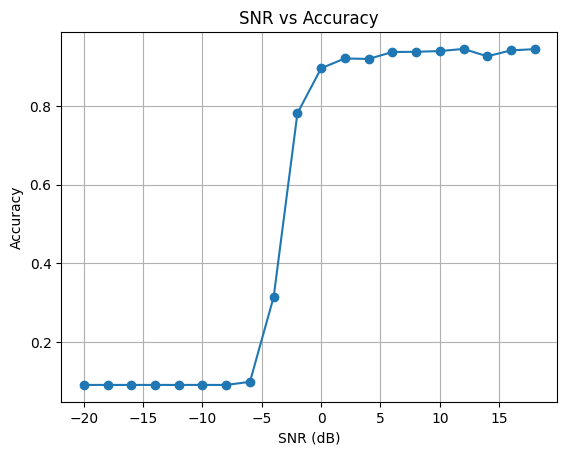

In [14]:

plt.figure()
plt.plot(snr_values, snr_acc, marker='o')
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("SNR vs Accuracy")
plt.grid()
plt.show()


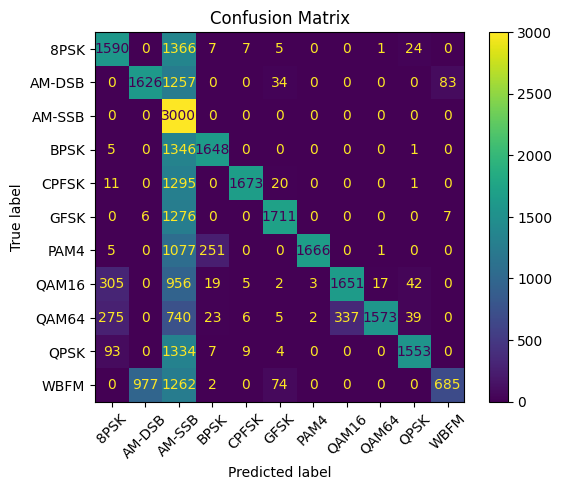

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for i in range(0, len(X_test_t), 128):
        Xb = X_test_t[i:i+128]
        yb = y_test_t[i:i+128]

        out = model(Xb, edge_index)
        preds = out.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [16]:
def test_sample(model, X_data, y_data, snr_data, idx, le, device, edge_index):

    model.eval()

    # -------- GET SAMPLE --------
    signal = X_data[idx]
    true_label = y_data[idx]
    true_snr = snr_data[idx]

    # -------- MODEL PREDICTION --------
    signal_t = torch.tensor(signal, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(signal_t, edge_index)
        pred = out.argmax(1).item()

    # -------- DECODE LABELS --------
    true_mod = le.inverse_transform([true_label])[0]
    pred_mod = le.inverse_transform([pred])[0]

    # -------- PRINT RESULT --------
    print(f"📡 Sample Index: {idx}")
    print(f"True Modulation : {true_mod}")
    print(f"True SNR        : {true_snr}")
    print(f"Predicted Mod   : {pred_mod}")

    # -------- RETURN (optional) --------
    return true_mod, true_snr, pred_mod

In [17]:
test_sample(
    model,
    X_test,
    y_test,
    snr_test,
    idx=10,
    le=le,
    device=device,
    edge_index=edge_index
)

📡 Sample Index: 10
True Modulation : BPSK
True SNR        : 14
Predicted Mod   : BPSK


('BPSK', 14, 'BPSK')

In [18]:
model_clean = CNN_GRU_GNN(num_classes=len(le.classes_)).to(device)
model_clean.load_state_dict(torch.load("best_model.pth"))
model_clean.eval()

model_robust = CNN_GRU_GNN(num_classes=len(le.classes_)).to(device)
model_robust.load_state_dict(torch.load("final_finetuned_model.pth"))
model_robust.eval()

print("✅ Both models loaded")

✅ Both models loaded


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12020\2759024626.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_clean.load_state_dict(torch.load("best_model.pth"))
C:

In [23]:
def adaptive_modulation_rule(snr):
    if snr < 0:
        return "BPSK"
    elif snr < 8:
        return "QPSK"
    elif snr < 15:
        return "QAM16"
    else:
        return "QAM64"

In [24]:
def select_model(snr):
    if snr >= 0:
        return model_clean
    else:
        return model_robust

In [25]:
def adaptive_amr_system(idx):

    # ----- get sample -----
    signal = X_test[idx]
    true_mod = le.inverse_transform([y_test[idx]])[0]
    snr_val = snr_test[idx]

    signal_t = torch.tensor(signal, dtype=torch.float32).unsqueeze(0).to(device)

    # ----- select model -----
    model = select_model(snr_val)

    # ----- predict -----
    with torch.no_grad():
        out = model(signal_t, edge_index)
        pred = out.argmax(1).item()

    pred_mod = le.inverse_transform([pred])[0]

    # ----- recommend modulation -----
    recommended_mod = adaptive_modulation_rule(snr_val)

    # ----- print -----
    print(f"\n📡 Sample {idx}")
    print(f"True Modulation     : {true_mod}")
    print(f"SNR                : {snr_val}")
    print(f"Predicted Mod      : {pred_mod}")
    print(f"Recommended Mod    : {recommended_mod}")

    return true_mod, snr_val, pred_mod, recommended_mod

In [26]:
adaptive_amr_system(10)


📡 Sample 10
True Modulation     : BPSK
SNR                : 14
Predicted Mod      : BPSK
Recommended Mod    : QAM16


('BPSK', 14, 'BPSK', 'QAM16')

In [44]:
# Explainable ai - saliency map - in our context - Which time steps in I/Q signal influenced the prediction the most?

def get_saliency_map(model, signal, edge_index, device):

    model.train()

    # prepare input
    signal_t = torch.tensor(signal, dtype=torch.float32).unsqueeze(0).to(device)
    signal_t.requires_grad = True

    # forward
    out = model(signal_t, edge_index)
    pred_class = out.argmax()

    # backward
    out[0, pred_class].backward()

    # gradients = importance
    saliency = signal_t.grad.abs().squeeze().cpu().numpy()
    saliency = saliency / (saliency.max() + 1e-8)

    return saliency, pred_class.item()

In [45]:
import matplotlib.pyplot as plt

def plot_saliency(signal, saliency, title="Saliency Map"):

    plt.figure(figsize=(10,4))

    # I channel
    plt.subplot(1,2,1)
    plt.plot(signal[0], label="Signal (I)")
    plt.plot(saliency[0], label="Saliency", alpha=0.7)
    plt.title("I Channel")
    plt.legend()

    # Q channel
    plt.subplot(1,2,2)
    plt.plot(signal[1], label="Signal (Q)")
    plt.plot(saliency[1], label="Saliency", alpha=0.7)
    plt.title("Q Channel")
    plt.legend()

    plt.suptitle(title)
    plt.show()

In [46]:
def explain_sample(idx):

    signal = X_test[idx]
    true_mod = le.inverse_transform([y_test[idx]])[0]
    snr_val = snr_test[idx]

    saliency, pred = get_saliency_map(model_robust, signal, edge_index, device)
    pred_mod = le.inverse_transform([pred])[0]

    print(f"\n📡 Sample {idx}")
    print(f"True Modulation : {true_mod}")
    print(f"SNR            : {snr_val}")
    print(f"Predicted      : {pred_mod}")

    plot_saliency(signal, saliency, title=f"{pred_mod} (SNR={snr_val})")


📡 Sample 10
True Modulation : BPSK
SNR            : 14
Predicted      : BPSK


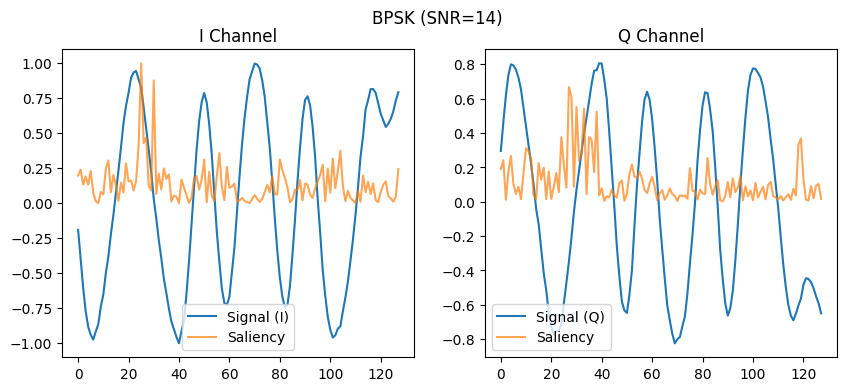

In [47]:
explain_sample(10) # Orange line shows which parts of the signal the model focused on.
# Higher peaks = more important for prediction.

In [2]:
import numpy as np

X_samples = []
y_labels = []
snr_values = []

count = 0

for (mod, snr), signals in data.items():

    for i in range(signals.shape[0]):

        X_samples.append(signals[i])   # (2,128)
        y_labels.append(mod)
        snr_values.append(snr)

        count += 1
        if count == 10:
            break

    if count == 10:
        break

# Convert to numpy
X_samples = np.array(X_samples)
y_labels = np.array(y_labels)
snr_values = np.array(snr_values)

print("✅ Extracted 10 samples")
print("X shape:", X_samples.shape)   # (10, 2, 128)
print("Labels:", y_labels)
print("SNR:", snr_values)

✅ Extracted 10 samples
X shape: (10, 2, 128)
Labels: ['QPSK' 'QPSK' 'QPSK' 'QPSK' 'QPSK' 'QPSK' 'QPSK' 'QPSK' 'QPSK' 'QPSK']
SNR: [2 2 2 2 2 2 2 2 2 2]


In [6]:
# pick any sample
(mod, snr), signals = list(data.items())[0]

sample = signals[50]   # shape (2,128)

I = sample[0]
Q = sample[1]

print("Mod:", mod)
print("SNR:", snr)

Mod: QPSK
SNR: 2


In [4]:
# convert to comma-separated string
I_str = ", ".join([f"{x:.4f}" for x in I])
Q_str = ", ".join([f"{x:.4f}" for x in Q])

print("\n=== COPY THIS ===\n")
print("I CHANNEL:")
print(I_str)

print("\nQ CHANNEL:")
print(Q_str)


=== COPY THIS ===

I CHANNEL:
0.0052, 0.0043, 0.0087, 0.0066, 0.0082, 0.0107, 0.0073, 0.0066, 0.0056, 0.0085, 0.0060, 0.0031, 0.0034, 0.0051, 0.0037, 0.0018, -0.0008, -0.0013, -0.0026, -0.0053, -0.0079, -0.0075, -0.0106, -0.0108, -0.0110, -0.0077, -0.0066, -0.0066, -0.0031, -0.0058, 0.0017, -0.0005, 0.0039, 0.0003, 0.0033, 0.0029, 0.0043, 0.0047, 0.0028, 0.0037, 0.0013, 0.0005, 0.0017, -0.0009, -0.0037, -0.0048, -0.0041, -0.0069, -0.0101, -0.0088, -0.0076, -0.0057, -0.0044, -0.0031, 0.0002, 0.0042, 0.0016, 0.0018, 0.0003, 0.0009, 0.0024, 0.0014, -0.0032, -0.0010, -0.0001, -0.0034, -0.0010, -0.0020, -0.0003, -0.0004, -0.0018, 0.0014, -0.0001, -0.0011, -0.0033, -0.0074, -0.0079, -0.0086, -0.0108, -0.0042, -0.0095, -0.0079, -0.0032, -0.0035, -0.0001, 0.0002, 0.0065, 0.0076, 0.0055, 0.0096, 0.0079, 0.0084, 0.0087, 0.0075, 0.0050, 0.0022, -0.0006, 0.0004, -0.0021, -0.0070, -0.0035, -0.0061, -0.0065, -0.0116, -0.0068, -0.0053, -0.0068, -0.0062, -0.0036, -0.0027, -0.0004, 0.0001, 0.0005, 0.0

In [23]:
import json

# ====================================
# FLATTEN DATASET
# ====================================

all_samples = []

for (mod, snr), signals in data.items():

    for i in range(signals.shape[0]):

        all_samples.append({
            "modulation": mod,
            "snr": snr,
            "signal": signals[i]
        })

print("✅ Total samples:", len(all_samples))


# ====================================
# CHANGE INDEX HERE
# ====================================

idx = 10   # <-- change sample index


# ====================================
# GET SAMPLE
# ====================================

sample = all_samples[idx]

mod = sample["modulation"]
snr = sample["snr"]

signal = sample["signal"]

I = signal[0].tolist()
Q = signal[1].tolist()


# ====================================
# CREATE JSON
# ====================================

sample_json = {
    "modulation": mod,
    "snr": int(snr),
    "iSamples": I,
    "qSamples": Q
}


# ====================================
# PRINT INFO
# ====================================

print("\n===================================")
print("INDEX:", idx)
print("MODULATION:", mod)
print("SNR:", snr)
print("===================================\n")

print(json.dumps(sample_json, indent=2))


# ====================================
# SAVE JSON FILE
# ====================================

filename = f"sample_{idx}.json"

with open(filename, "w") as f:
    json.dump(sample_json, f, indent=2)

print(f"\n✅ Saved JSON file: {filename}")

✅ Total samples: 220000

INDEX: 10
MODULATION: QPSK
SNR: 2

{
  "modulation": "QPSK",
  "snr": 2,
  "iSamples": [
    -0.004925633780658245,
    -0.006962258368730545,
    -0.00463648047298193,
    -0.004225738812237978,
    -0.0008700374164618552,
    -0.0006486921920441091,
    -0.005106189288198948,
    -0.0027521317824721336,
    -0.007441721390932798,
    -0.004331558011472225,
    -0.004574218299239874,
    -0.004364064894616604,
    -0.007460873108357191,
    -0.006733547430485487,
    -0.007785910274833441,
    -0.003564341925084591,
    -0.008818679489195347,
    -0.008616427890956402,
    -0.00587061420083046,
    -0.003016854403540492,
    -0.004696379881352186,
    -0.003017157083377242,
    -0.007634471636265516,
    -0.002083738800138235,
    -0.002378488890826702,
    -0.002468497958034277,
    -0.005277210846543312,
    -0.005123377311974764,
    -0.005599389784038067,
    -0.00472259009256959,
    -0.006361891981214285,
    -0.006631060969084501,
    -0.007275477983057

In [10]:
print(list(data.keys())[:10])

[('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8), ('AM-SSB', 12), ('8PSK', 8), ('8PSK', 12), ('QAM64', -6), ('QAM16', 2)]
